- Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
- Project the dataset into the principal components, and do a scatter plot of the first two. 
- This will look terrible. Think about the units!
- Explore what happens if you rescale the data first.

**This is actually a very important lesson in machine learning**: Massaging your data before giving them to an algorithm can make things much much better.

- You can try an linear, affine transformation such that each dimension goes between -1 and 1.
- Or (which is [the usual machine-learning approach](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) standardize your data such that each dimension has mean=0 and variance=1. 
- Redo your PCA. Should be much much better.
- How much variance is explained by those two components?


### Part 2. [Optional, not examinable] For later: come back to this assignment after lecture 20
- Now run a supervised classification algorithm on this dataset. 
- Can you predict the stellar type? How well? Careful with overfitting of course.

In [26]:
import urllib.request
import pandas as pd
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
df_stars = pd.read_csv("stars.csv")
print(df_stars.columns)

Index(['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
       'Absolute magnitude(Mv)', 'Star type', 'Star color', 'Spectral Class'],
      dtype='object')


In [27]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
# df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
# labels = le.inverse_transform(df_stars['Star type'])
# class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [29]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
n_components = 2 
pca = PCA(n_components=n_components)
pca.fit(df_stars.iloc[:, :4])
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [0.99760631 0.0023879 ]


99.7% of the variance is in the first component, 0.2% in the second

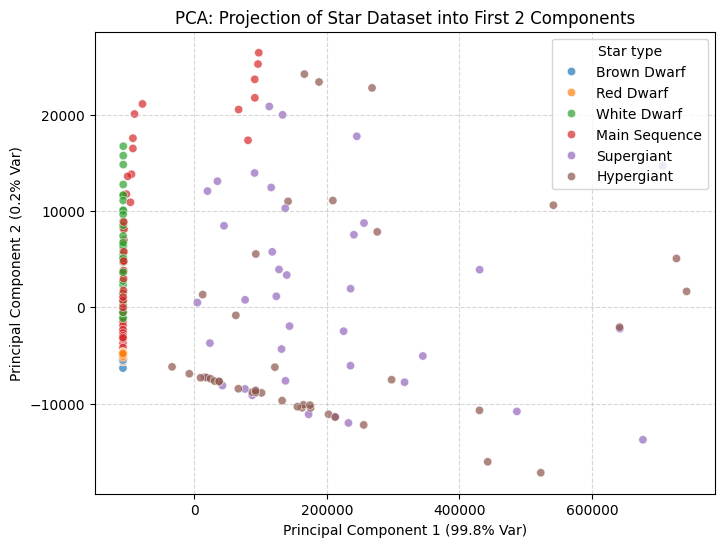

In [31]:

X_pca = pca.transform(df_stars.iloc[:, :4])

# 4. Do a scatter plot of the first two principal components
plt.figure(figsize=(8, 6))

# If you have a target/class column (like star type) in df_stars,
# you can pass it to 'hue' to color the points!
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.7, edgecolors='w', hue = df_stars['Star type'])

plt.title('PCA: Projection of Star Dataset into First 2 Components')
plt.xlabel(f'Principal Component 1 ({evals[0]:.1%} Var)')
plt.ylabel(f'Principal Component 2 ({evals[1]:.1%} Var)')
# plt.yscale('log')
# plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

the pca spends much more time on components as temperature or luminosity because they have an higher delta of values respect to absolute magnitude: 10^9 vs 10^1

need to rescale the initial values to better split the time spent in each component

In [ ]:
from sklearn.preprocessing import StandardScaler
#a function that do the mean for each column, subtract it for eac value of the column, 
#divide each value for the standar deviation so that the variance is 1
scaler = StandardScaler()

x_scaled = scaler.fit_transform(df_stars.iloc[:, :4])

In [33]:
pca.fit(x_scaled)
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784]


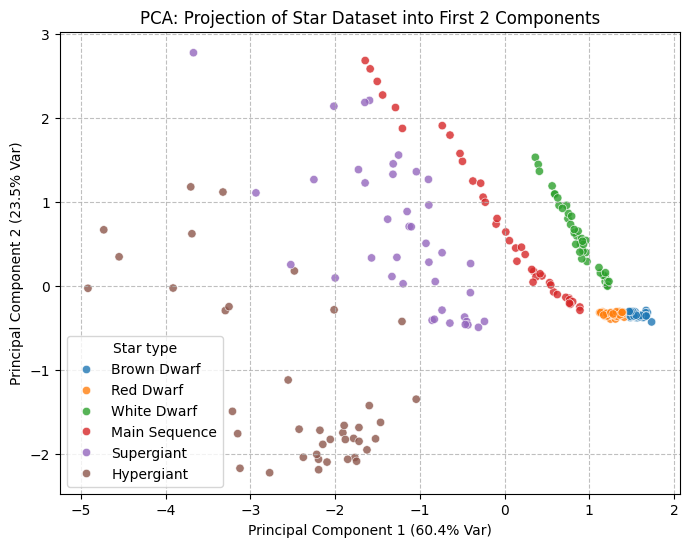

In [34]:

X_pca = pca.transform(x_scaled)

# 4. Do a scatter plot of the first two principal components
plt.figure(figsize=(8, 6))

# If you have a target/class column (like star type) in df_stars,
# you can pass it to 'hue' to color the points!
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.8, edgecolors='w', hue = df_stars['Star type'])

plt.title('PCA: Projection of Star Dataset into First 2 Components')
plt.xlabel(f'Principal Component 1 ({evals[0]:.1%} Var)')
plt.ylabel(f'Principal Component 2 ({evals[1]:.1%} Var)')
# plt.yscale('log')
# plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()

below there is the scaling of max-min = [-1, 1]. it's good but sensible to outliers: if there is one far away from the mean all the other points would be compressed

Expained fractional variance of data encapsulated in the eigenvalues: [0.63752162 0.21432776]


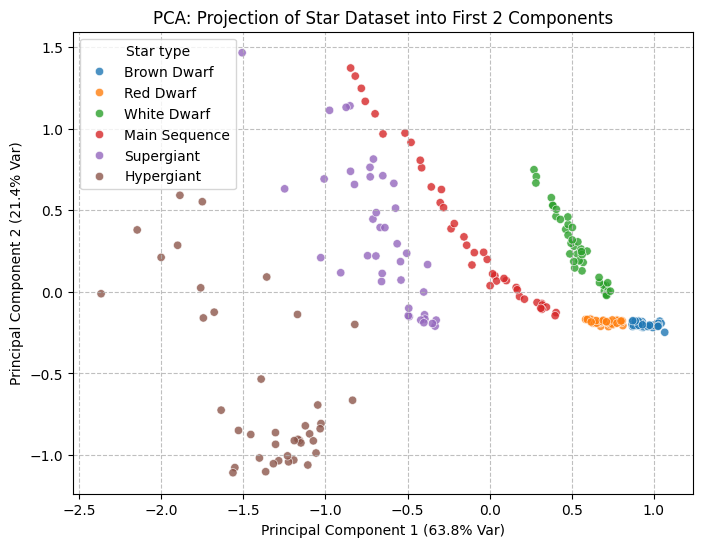

In [40]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler to bound data between -1 and 1
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit and transform your star data
x_scaled_minmax = scaler.fit_transform(df_stars.iloc[:, :4])
pca.fit(x_scaled_minmax)
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))


X_pca = pca.transform(x_scaled_minmax)

# 4. Do a scatter plot of the first two principal components
plt.figure(figsize=(8, 6))

# If you have a target/class column (like star type) in df_stars,
# you can pass it to 'hue' to color the points!
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.8, edgecolors='w', hue = df_stars['Star type'])

plt.title('PCA: Projection of Star Dataset into First 2 Components')
plt.xlabel(f'Principal Component 1 ({evals[0]:.1%} Var)')
plt.ylabel(f'Principal Component 2 ({evals[1]:.1%} Var)')
# plt.yscale('log')
# plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()